# 판별식

이차방정식 $ax^2 + bx + c = 0$ $(a \neq 0)$ 의 판별식:

$$
D = b^2 - 4ac
$$

| $D$ | 근의 성질 |
|-----|----------|
| $D > 0$ | 서로 다른 두 실근 |
| $D = 0$ | 중근 (실근 하나) |
| $D < 0$ | 서로 다른 두 허근 |

## 1. 기본: 계수 추출 → 판별식

In [ ]:
import sympy as sp
sp.init_printing()

x = sp.symbols('x')
expr = x**2 + 3*x - 6

poly = sp.Poly(expr, x)
coeffs = poly.all_coeffs()

if len(coeffs) == 3:
    a, b, c = coeffs
elif len(coeffs) == 2:
    a, b, c = 0, coeffs[0], coeffs[1]
else:
    a, b, c = 0, 0, coeffs[0]

def dcm(a, b, c):
    return b**2 - 4*a*c

re = dcm(a, b, c)

print("식:")
display(expr)
print(f"계수: a={a}, b={b}, c={c}")
print(f"판별식: {re}")

if re > 0:
    print("서로 다른 두 실근")
elif re == 0:
    print("중근")
else:
    print("서로 다른 두 허근")

**sp.Poly()**: <br>
=> 다항식을 표현하는 함수

**sp.Poly(expr, x).all_coeffs()**: <br>
=> 다항식의 계수를 최고차항부터 추출

**sp.discriminant(poly)**: <br>
=> sympy 내장 판별식 (아래 7절)

In [10]:
def discriminant(a, b, c):
    return b**2 - 4*a*c

discriminant(1, 2, 3)  # → -8

-8

## 2. 세 케이스 비교 ($D>0$, $D=0$, $D<0$)

In [ ]:
examples = [
    x**2 - 5*x + 6,   # D > 0
    x**2 - 4*x + 4,   # D = 0
    x**2 + 2*x + 5,   # D < 0
]

for expr in examples:
    poly = sp.Poly(expr, x)
    a, b, c = poly.all_coeffs()
    D = discriminant(a, b, c)
    roots = sp.solve(expr, x)

    print("=" * 40)
    display(sp.Eq(expr, 0))
    print(f"D = {D}")
    print("근:")
    display(roots)

## 3. 근의 공식과의 연결

$$
x = \frac{-b \pm \sqrt{D}}{2a}
$$

- $D > 0$: 제곱근이 실수 → 서로 다른 두 실근
- $D = 0$: $\pm$ 가 같아짐 → 중근 $x = -\dfrac{b}{2a}$
- $D < 0$: 제곱근이 허수 → 서로 다른 두 허근

In [ ]:
def quadratic_roots(a, b, c):
    D = discriminant(a, b, c)
    return (
        (-b + sp.sqrt(D)) / (2*a),
        (-b - sp.sqrt(D)) / (2*a),
    )

r1, r2 = quadratic_roots(1, -5, 6)
print("x^2 - 5x + 6 = 0 의 근:")
display(r1, r2)

r1, r2 = quadratic_roots(1, 2, 5)
print("x^2 + 2x + 5 = 0 의 근 (허근):")
display(sp.simplify(r1), sp.simplify(r2))

## 4. 완전제곱식과 $D = 0$

$$
D = 0 \iff ax^2 + bx + c = a\left(x + \frac{b}{2a}\right)^2
$$

(상수항까지 맞아떨어질 때 — 즉 중근을 가질 때)

In [ ]:
expr = x**2 - 4*x + 4
a, b, c = sp.Poly(expr, x).all_coeffs()
D = discriminant(a, b, c)

print(f"D = {D}")
print("인수분해:")
display(sp.factor(expr))

# D = 0 이면 a(x + b/(2a))^2 형태
completed = sp.simplify(a * (x + b/(2*a))**2)
print("완전제곱으로 변형:")
display(sp.Eq(expr, completed))
print(f"항등식인가?: {sp.expand(completed) == expr}")

## 5. 그래프 관점 ($x$축 교점 개수)

| $D$ | 포물선 $y = ax^2+bx+c$ |
|-----|------------------------|
| $D > 0$ | $x$축과 **두 점**에서 만남 |
| $D = 0$ | $x$축에 **접함** (한 점) |
| $D < 0$ | $x$축과 **만나지 않음** |

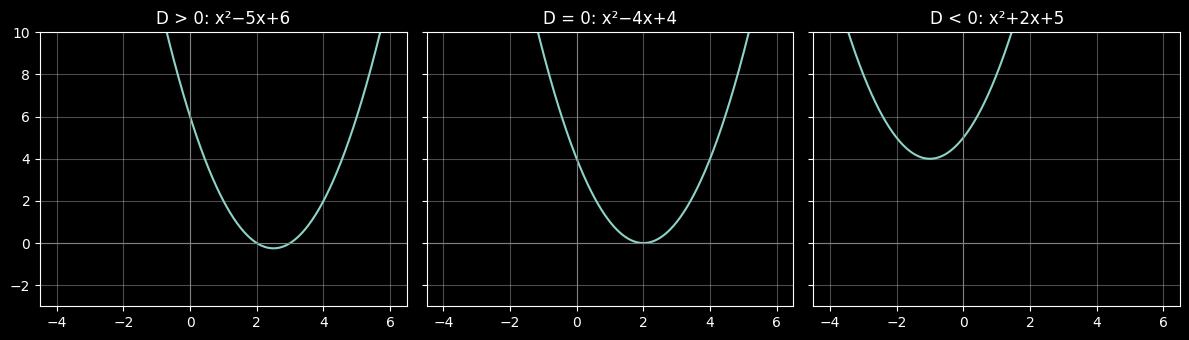

In [11]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-4, 6, 400)
curves = [
    (1, -5, 6, "D > 0: x²−5x+6"),
    (1, -4, 4, "D = 0: x²−4x+4"),
    (1,  2, 5, "D < 0: x²+2x+5"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (a, b, c, title) in zip(axes, curves):
    ys = a*xs**2 + b*xs + c
    ax.plot(xs, ys)
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(title)
    ax.set_ylim(-3, 10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 계수에 문자 — 실근 조건

Ex) $x^2 - (k+1)x + k = 0$ 이 **서로 다른 두 실근**을 가질 조건

$$
D = (k+1)^2 - 4k > 0
$$

In [ ]:
k = sp.symbols('k', real=True)
a, b, c = 1, -(k + 1), k
D = sp.simplify(discriminant(a, b, c))

print("판별식 D(k):")
display(D)

print("서로 다른 두 실근 조건 D > 0:")
display(sp.solve_univariate_inequality(D > 0, k))

print("중근 조건 D = 0:")
display(sp.solve(D, k))

## 6-2. 중근 / "접한다" 조건

이차함수 $y = x^2 - 2x + m$ 이 $x$축에 **접할** 조건 → $D = 0$

In [ ]:
m = sp.symbols('m', real=True)
expr = x**2 - 2*x + m
a, b, c = sp.Poly(expr, x).all_coeffs()
D = discriminant(a, b, c)

print("D =")
display(D)

m_touch = sp.solve(D, m)[0]
print(f"접하는 m = {m_touch}")
print("그때의 식 / 근:")
display(expr.subs(m, m_touch))
display(sp.solve(expr.subs(m, m_touch), x))

## 7. sympy 내장 판별식과 비교

In [ ]:
expr = x**2 + 3*x - 6
poly = sp.Poly(expr, x)
a, b, c = poly.all_coeffs()

manual = discriminant(a, b, c)
builtin = sp.discriminant(poly)

print(f"직접 계산: {manual}")
print(f"sp.discriminant: {builtin}")
print(f"일치?: {manual == builtin}")

## 8. 고차 방정식 맛보기

삼차 이상도 판별식이 있지만, 이차처럼 $b^2-4ac$ 한 줄로 끝나지 않는다.

- 삼차: 더 복잡한 식 (casus irreducibilis 등과 연결)
- 실습/인수분해는 `higher-order_equations.ipynb` 참고

근과 계수의 관계(합·곱)는 `Viète's_formulas.ipynb`,  
허근 연산은 `Complex_Number.ipynb`,  
이차부등식은 `Quadratic_Inequality.ipynb`.

In [ ]:
# 삼차 다항식에도 discriminant는 정의됨 (값이 0이면 중근 존재)
cubic = sp.Poly(x**3 - 3*x + 2, x)
print("삼차식:")
display(cubic.as_expr())
print(f"판별식: {sp.discriminant(cubic)}")
print("인수분해:")
display(sp.factor(cubic.as_expr()))